# Ejercicio 3: SGD y sus variantes en redes neuronales

**Opción elegida: 3.2 — SGD y sus variantes en redes neuronales para regresión**

Equipo: Raúl Llamosas Alvarado, Eumir Rendon Uresti, Gabriela Peña Franco, Daniela Ibarra Gatica.

Las instrucciones para reproducir esta tarea se encuentran en el [repositorio del equipo](https://github.com/MelodiousZero/tareas_modulo_7_diplomado), en particular la sección de *Setup* del `README.md`.

## 1. Descripción del problema

Queremos resolver un problema de **regresión con datos reales** usando una **red neuronal multicapa (MLP)** y comparar el comportamiento de diferentes optimizadores durante el entrenamiento de **una misma arquitectura**.

Usamos la base de datos **California Housing** (la misma que empleamos en el Ejercicio 2), que contiene 8 covariables por distrito censal de California (ingreso mediano, edad mediana de las viviendas, promedio de cuartos, promedio de recámaras, población, ocupación promedio, latitud y longitud) y como variable respuesta el **valor mediano de la vivienda** (en unidades de \$100,000 USD). El objetivo es predecir dicho valor a partir de las covariables.

Manteniendo fija la arquitectura de la red, la inicialización de los pesos y el tamaño de minilote, entrenamos con seis optimizadores distintos:

1. **SGD** clásico
2. **SGD con momentum**
3. **AdaGrad**
4. **RMSProp**
5. **Adam**
6. **AdamW**

y comparamos su velocidad de convergencia, su error final en validación y prueba (MSE, MAE, RMSE y $R^2$), la presencia de sobreajuste y su sensibilidad a la tasa de aprendizaje.

## 2. Metodología

1. **Exploración de la base de datos**: estadísticas descriptivas y distribución de la variable respuesta.
2. **Partición de los datos** en entrenamiento (60%), validación (20%) y prueba (20%).
3. **Estandarización** de las variables explicativas con `StandardScaler`, ajustado *únicamente* con el conjunto de entrenamiento para evitar fuga de información.
4. **Arquitectura fija**: red multicapa sencilla $8 \to 64 \to 32 \to 1$ con activaciones ReLU en las capas ocultas y salida lineal, entrenada con pérdida **MSE**. Implementamos la red y la retropropagación **desde cero con NumPy** (igual que en el Ejercicio 1), y verificamos numéricamente el gradiente.
5. **Optimizadores implementados desde cero**, todos con la misma inicialización (misma semilla) y minilotes de 256 observaciones. Con $g_n = \nabla \ell(\theta_n)$ el gradiente del minilote:

   * **SGD**: $\theta_{n+1} = \theta_n - \eta\, g_n$
   * **SGD con momentum**: $v_{n+1} = \beta v_n + g_n$, $\quad \theta_{n+1} = \theta_n - \eta\, v_{n+1}$
   * **AdaGrad**: $G_{n+1} = G_n + g_n^2$, $\quad \theta_{n+1} = \theta_n - \dfrac{\eta}{\sqrt{G_{n+1}} + \epsilon}\, g_n$
   * **RMSProp**: $G_{n+1} = \rho G_n + (1-\rho) g_n^2$, $\quad \theta_{n+1} = \theta_n - \dfrac{\eta}{\sqrt{G_{n+1}} + \epsilon}\, g_n$
   * **Adam**: $m_{n+1} = \rho_1 m_n + (1-\rho_1) g_n$, $\; v_{n+1} = \rho_2 v_n + (1-\rho_2) g_n^2$, con corrección de sesgo $\hat m = m_{n+1}/(1-\rho_1^{n+1})$, $\hat v = v_{n+1}/(1-\rho_2^{n+1})$ y $\theta_{n+1} = \theta_n - \eta\, \hat m / (\sqrt{\hat v} + \epsilon)$
   * **AdamW**: igual que Adam pero con *weight decay* desacoplado: $\theta_{n+1} = \theta_n - \eta\, \big(\hat m / (\sqrt{\hat v} + \epsilon) + \lambda\, \theta_n\big)$

   Las tasas de aprendizaje se eligieron del orden típico para cada método ($\eta = 0.01$ para SGD y momentum, $0.05$ para AdaGrad, $0.005$ para RMSProp, Adam y AdamW).
6. **Registro por época** de la pérdida (MSE) en entrenamiento y validación para cada optimizador.
7. **Evaluación final** en el conjunto de prueba con MSE, MAE, RMSE y $R^2$, comparando además contra una **regresión lineal ordinaria** como referencia (conectando con el Ejercicio 2).
8. **Experimento de sensibilidad**: reentrenamos SGD y Adam con $\eta \in \{0.1,\ 0.01,\ 0.001\}$ para estudiar el efecto de la tasa de aprendizaje.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEMILLA = 42
np.random.seed(SEMILLA)

### a) Exploración de la base de datos

Cargamos **California Housing**. Usamos `fetch_california_housing` de scikit-learn; si la descarga fallara (p. ej. sin acceso a figshare), reconstruimos exactamente las mismas 8 covariables a partir de una copia pública del archivo original de StatLib.

In [2]:
def cargar_california_housing():
    try:
        from sklearn.datasets import fetch_california_housing
        datos = fetch_california_housing()
        X = pd.DataFrame(datos.data, columns=datos.feature_names)
        y = pd.Series(datos.target, name='MedHouseVal')
        print('Datos cargados con fetch_california_housing (scikit-learn).')
    except Exception as e:
        # Respaldo: copia pública del dataset original; construimos las mismas variables
        # que scikit-learn (se descartan 207 renglones con faltantes en total_bedrooms).
        print('fetch_california_housing falló, usando respaldo de GitHub...')
        url = 'https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv'
        df = pd.read_csv(url).dropna()
        X = pd.DataFrame({
            'MedInc': df['median_income'],
            'HouseAge': df['housing_median_age'],
            'AveRooms': df['total_rooms'] / df['households'],
            'AveBedrms': df['total_bedrooms'] / df['households'],
            'Population': df['population'],
            'AveOccup': df['population'] / df['households'],
            'Latitude': df['latitude'],
            'Longitude': df['longitude'],
        }).reset_index(drop=True)
        y = pd.Series(df['median_house_value'].values / 100000.0, name='MedHouseVal')
    return X, y

X_df, y_s = cargar_california_housing()
print('Dimensiones:', X_df.shape, y_s.shape)
X_df.describe().T.round(3)

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_base.py:1519: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976036
  warnings.warn(f"Retry downloading from url: {remote.url}")


fetch_california_housing falló, usando respaldo de GitHub...


Dimensiones: (20433, 8) (20433,)


,count,mean,std,min,25%,50%,75%,max
MedInc,20433.0,3.871,1.899,0.500,2.564,3.536,4.744,15.000
HouseAge,20433.0,28.633,12.592,1.000,18.000,29.000,37.000,52.000
AveRooms,20433.0,5.431,2.483,0.846,4.441,5.231,6.052,141.909
AveBedrms,20433.0,1.097,0.476,0.333,1.006,1.049,1.100,34.067
Population,20433.0,1424.947,1133.208,3.000,787.000,1166.000,1722.000,35682.000
AveOccup,20433.0,3.072,10.438,0.692,2.429,2.818,3.282,1243.333
Latitude,20433.0,35.633,2.136,32.540,33.930,34.260,37.720,41.950
Longitude,20433.0,-119.571,2.004,-124.350,-121.800,-118.490,-118.010,-114.310


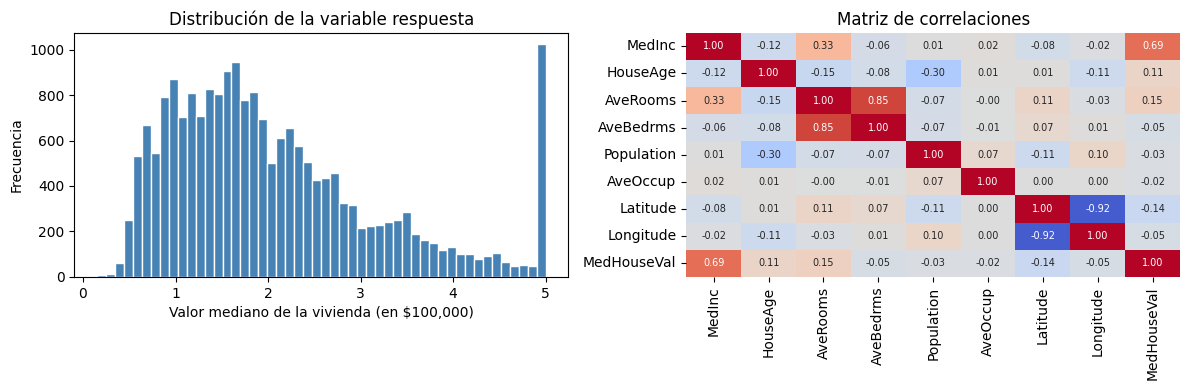

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].hist(y_s, bins=50, color='steelblue', edgecolor='white')
axs[0].set_xlabel('Valor mediano de la vivienda (en $100,000)')
axs[0].set_ylabel('Frecuencia')
axs[0].set_title('Distribución de la variable respuesta')

corr = pd.concat([X_df, y_s], axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axs[1], annot_kws={'size': 7}, cbar=False)
axs[1].set_title('Matriz de correlaciones')
plt.tight_layout()
plt.show()

**Observaciones**: la variable respuesta está acotada en $[0.15, 5]$ (los valores mayores a \$500,000 fueron censurados en el levantamiento original, lo que produce el pico en 5). La covariable más correlacionada con el precio es el ingreso mediano (`MedInc`). Las escalas de las covariables son muy distintas (p. ej. `Population` vs. `Latitude`), por lo que la **estandarización es indispensable** para que el descenso de gradiente funcione bien.

### b) y c) Partición entrenamiento/validación/prueba y estandarización

In [4]:
X = X_df.to_numpy()
y = y_s.to_numpy()

# 60% entrenamiento, 20% validación, 20% prueba
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.4, random_state=SEMILLA)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=SEMILLA)

# Estandarizamos SOLO con estadísticas del conjunto de entrenamiento
escalador = StandardScaler()
X_train = escalador.fit_transform(X_train)
X_val = escalador.transform(X_val)
X_test = escalador.transform(X_test)

print(f'Entrenamiento: {X_train.shape[0]} | Validación: {X_val.shape[0]} | Prueba: {X_test.shape[0]}')

Entrenamiento: 12259 | Validación: 4087 | Prueba: 4087


### d) Red neuronal multicapa

Implementamos una MLP $8 \to 64 \to 32 \to 1$ con ReLU y salida lineal. La clase calcula el paso hacia adelante y la retropropagación del gradiente de la pérdida MSE
$$\ell(\theta) = \frac{1}{m}\sum_{i=1}^{m} (\hat y_i - y_i)^2,$$
respecto de todos los pesos y sesgos. Usamos inicialización de He (adecuada para ReLU) con semilla fija, de modo que **todos los optimizadores parten exactamente de los mismos pesos iniciales**.

In [5]:
class MLP:
    """Red multicapa 8 -> 64 -> 32 -> 1 (ReLU, salida lineal) con pérdida MSE."""

    def __init__(self, n_entradas, n_oculta1=64, n_oculta2=32, semilla=SEMILLA):
        rng = np.random.default_rng(semilla)
        # Inicialización de He: N(0, sqrt(2 / n_entradas_de_la_capa))
        self.params = {
            'W1': rng.normal(0, np.sqrt(2 / n_entradas), (n_entradas, n_oculta1)),
            'b1': np.zeros(n_oculta1),
            'W2': rng.normal(0, np.sqrt(2 / n_oculta1), (n_oculta1, n_oculta2)),
            'b2': np.zeros(n_oculta2),
            'W3': rng.normal(0, np.sqrt(2 / n_oculta2), (n_oculta2, 1)),
            'b3': np.zeros(1),
        }

    def forward(self, X):
        p = self.params
        self.X = X
        self.Z1 = X @ p['W1'] + p['b1']
        self.A1 = np.maximum(0, self.Z1)          # ReLU
        self.Z2 = self.A1 @ p['W2'] + p['b2']
        self.A2 = np.maximum(0, self.Z2)          # ReLU
        self.salida = (self.A2 @ p['W3'] + p['b3']).ravel()
        return self.salida

    def backward(self, y):
        """Gradiente de la pérdida MSE respecto de cada parámetro (retropropagación)."""
        p = self.params
        m = len(y)
        grads = {}
        d_salida = (2.0 / m) * (self.salida - y)[:, None]     # dL/d(salida)
        grads['W3'] = self.A2.T @ d_salida
        grads['b3'] = d_salida.sum(axis=0)
        dA2 = d_salida @ p['W3'].T
        dZ2 = dA2 * (self.Z2 > 0)                             # derivada de ReLU
        grads['W2'] = self.A1.T @ dZ2
        grads['b2'] = dZ2.sum(axis=0)
        dA1 = dZ2 @ p['W2'].T
        dZ1 = dA1 * (self.Z1 > 0)
        grads['W1'] = self.X.T @ dZ1
        grads['b1'] = dZ1.sum(axis=0)
        return grads

    def perdida(self, X, y):
        return np.mean((self.forward(X) - y) ** 2)

**Verificación numérica del gradiente.** Antes de entrenar, comprobamos que la retropropagación está bien implementada comparando contra diferencias finitas centradas: $\partial \ell / \partial \theta_j \approx \big(\ell(\theta + \epsilon e_j) - \ell(\theta - \epsilon e_j)\big) / 2\epsilon$. Un error relativo del orden de $10^{-7}$ o menor indica que el gradiente analítico es correcto.

In [6]:
def verificar_gradiente(epsilon=1e-6):
    rng = np.random.default_rng(0)
    red = MLP(5, n_oculta1=8, n_oculta2=6, semilla=0)
    # ReLU no es diferenciable en 0; desplazamos los sesgos para evaluar el
    # gradiente en un punto alejado de los quiebres y evitar falsos errores.
    red.params['b1'] += 0.1
    red.params['b2'] += 0.1
    X_chico = rng.normal(size=(12, 5))
    y_chico = rng.normal(size=12)
    red.forward(X_chico)
    grads = red.backward(y_chico)
    errores = {}
    for clave in red.params:
        numerico = np.zeros_like(red.params[clave])
        it = np.nditer(red.params[clave], flags=['multi_index'])
        for _ in it:
            idx = it.multi_index
            red.params[clave][idx] += epsilon
            perdida_mas = red.perdida(X_chico, y_chico)
            red.params[clave][idx] -= 2 * epsilon
            perdida_menos = red.perdida(X_chico, y_chico)
            red.params[clave][idx] += epsilon
            numerico[idx] = (perdida_mas - perdida_menos) / (2 * epsilon)
        errores[clave] = np.max(np.abs(numerico - grads[clave]) /
                                (np.abs(numerico) + np.abs(grads[clave]) + 1e-12))
    for clave, err in errores.items():
        print(f'  {clave}: error relativo máximo = {err:.2e}')

verificar_gradiente()

  W1: error relativo máximo = 9.70e-07
  b1: error relativo máximo = 1.14e-09
  W2: error relativo máximo = 7.50e-09
  b2: error relativo máximo = 1.18e-09
  W3: error relativo máximo = 1.71e-08
  b3: error relativo máximo = 1.40e-10


### e) Optimizadores

Cada optimizador se implementa como una clase con un método `update(params, grads)` que aplica su regla de actualización (ver Metodología). Así garantizamos que lo **único** que cambia entre corridas es el optimizador.

In [7]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr
    def update(self, params, grads):
        for k in params:
            params[k] -= self.lr * grads[k]


class SGDMomentum:
    def __init__(self, lr=0.01, beta=0.9):
        self.lr, self.beta, self.v = lr, beta, {}
    def update(self, params, grads):
        for k in params:
            self.v[k] = self.beta * self.v.get(k, 0.0) + grads[k]
            params[k] -= self.lr * self.v[k]


class AdaGrad:
    def __init__(self, lr=0.05, epsilon=1e-8):
        self.lr, self.epsilon, self.G = lr, epsilon, {}
    def update(self, params, grads):
        for k in params:
            self.G[k] = self.G.get(k, 0.0) + grads[k] ** 2
            params[k] -= self.lr * grads[k] / (np.sqrt(self.G[k]) + self.epsilon)


class RMSProp:
    def __init__(self, lr=0.005, rho=0.9, epsilon=1e-8):
        self.lr, self.rho, self.epsilon, self.G = lr, rho, epsilon, {}
    def update(self, params, grads):
        for k in params:
            self.G[k] = self.rho * self.G.get(k, 0.0) + (1 - self.rho) * grads[k] ** 2
            params[k] -= self.lr * grads[k] / (np.sqrt(self.G[k]) + self.epsilon)


class Adam:
    def __init__(self, lr=0.005, rho1=0.9, rho2=0.999, epsilon=1e-8):
        self.lr, self.rho1, self.rho2, self.epsilon = lr, rho1, rho2, epsilon
        self.m, self.v, self.t = {}, {}, 0
    def update(self, params, grads):
        self.t += 1
        for k in params:
            self.m[k] = self.rho1 * self.m.get(k, 0.0) + (1 - self.rho1) * grads[k]
            self.v[k] = self.rho2 * self.v.get(k, 0.0) + (1 - self.rho2) * grads[k] ** 2
            m_hat = self.m[k] / (1 - self.rho1 ** self.t)   # corrección de sesgo
            v_hat = self.v[k] / (1 - self.rho2 ** self.t)
            params[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)


class AdamW(Adam):
    """Adam con weight decay desacoplado (Loshchilov & Hutter, 2019)."""
    def __init__(self, lr=0.005, rho1=0.9, rho2=0.999, epsilon=1e-8, wd=1e-4):
        super().__init__(lr, rho1, rho2, epsilon)
        self.wd = wd
    def update(self, params, grads):
        self.t += 1
        for k in params:
            self.m[k] = self.rho1 * self.m.get(k, 0.0) + (1 - self.rho1) * grads[k]
            self.v[k] = self.rho2 * self.v.get(k, 0.0) + (1 - self.rho2) * grads[k] ** 2
            m_hat = self.m[k] / (1 - self.rho1 ** self.t)
            v_hat = self.v[k] / (1 - self.rho2 ** self.t)
            params[k] -= self.lr * (m_hat / (np.sqrt(v_hat) + self.epsilon) + self.wd * params[k])

In [8]:
def entrenar(red, optimizador, X_train, y_train, X_val, y_val,
             epocas=100, tam_lote=256, semilla=SEMILLA):
    """Entrena la red con minilotes y registra la pérdida (MSE) por época."""
    rng = np.random.default_rng(semilla)
    n = X_train.shape[0]
    hist_train, hist_val = [], []
    for _ in range(epocas):
        indices = rng.permutation(n)
        for i in range(0, n, tam_lote):
            lote = indices[i:i + tam_lote]
            red.forward(X_train[lote])
            grads = red.backward(y_train[lote])
            optimizador.update(red.params, grads)
        hist_train.append(red.perdida(X_train, y_train))
        hist_val.append(red.perdida(X_val, y_val))
    return hist_train, hist_val

Entrenamos la **misma arquitectura** (misma semilla de inicialización y mismo orden de minilotes) con los seis optimizadores durante 100 épocas.

In [9]:
EPOCAS = 100

optimizadores = {
    'SGD':            lambda: SGD(lr=0.01),
    'SGD + Momentum': lambda: SGDMomentum(lr=0.01, beta=0.9),
    'AdaGrad':        lambda: AdaGrad(lr=0.05),
    'RMSProp':        lambda: RMSProp(lr=0.005),
    'Adam':           lambda: Adam(lr=0.005),
    'AdamW':          lambda: AdamW(lr=0.005, wd=1e-4),
}

historiales = {}
modelos = {}
for nombre, crear_opt in optimizadores.items():
    red = MLP(X_train.shape[1], semilla=SEMILLA)
    hist_train, hist_val = entrenar(red, crear_opt(), X_train, y_train, X_val, y_val, epocas=EPOCAS)
    historiales[nombre] = (hist_train, hist_val)
    modelos[nombre] = red
    print(f'{nombre:15s} | MSE entrenamiento: {hist_train[-1]:.4f} | MSE validación: {hist_val[-1]:.4f}')

SGD             | MSE entrenamiento: 0.3356 | MSE validación: 0.3437


SGD + Momentum  | MSE entrenamiento: 0.2671 | MSE validación: 0.2931


AdaGrad         | MSE entrenamiento: 0.2707 | MSE validación: 0.2936


RMSProp         | MSE entrenamiento: 0.2510 | MSE validación: 0.3241


Adam            | MSE entrenamiento: 0.2326 | MSE validación: 0.2831


AdamW           | MSE entrenamiento: 0.2287 | MSE validación: 0.2740


## 3. Resultados

### g) Curvas de pérdida en entrenamiento y validación

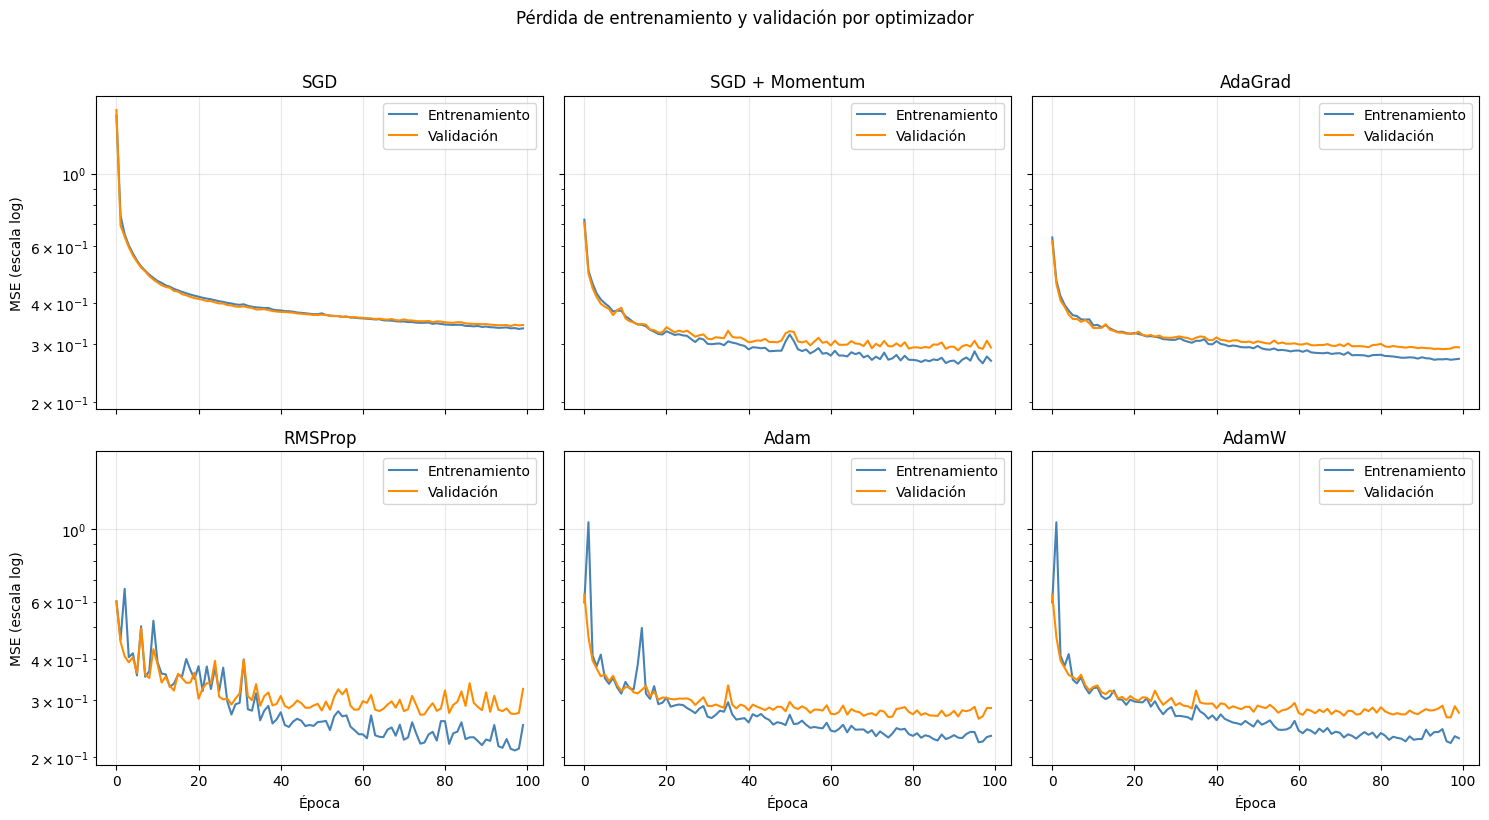

In [10]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for ax, (nombre, (hist_train, hist_val)) in zip(axs.ravel(), historiales.items()):
    ax.plot(hist_train, label='Entrenamiento', color='steelblue')
    ax.plot(hist_val, label='Validación', color='darkorange')
    ax.set_title(nombre)
    ax.set_yscale('log')
    ax.grid(alpha=0.3)
    ax.legend()
for ax in axs[1]:
    ax.set_xlabel('Época')
for ax in axs[:, 0]:
    ax.set_ylabel('MSE (escala log)')
plt.suptitle('Pérdida de entrenamiento y validación por optimizador', y=1.02)
plt.tight_layout()
plt.show()

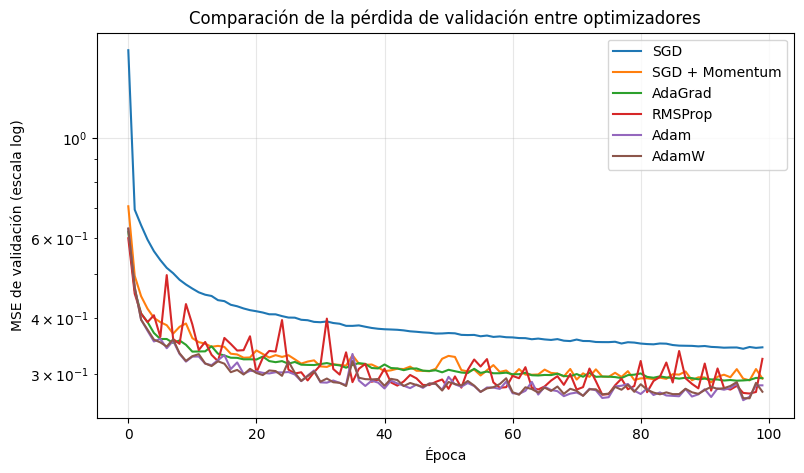

In [11]:
plt.figure(figsize=(9, 5))
for nombre, (hist_train, hist_val) in historiales.items():
    plt.plot(hist_val, label=nombre)
plt.yscale('log')
plt.xlabel('Época')
plt.ylabel('MSE de validación (escala log)')
plt.title('Comparación de la pérdida de validación entre optimizadores')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### f) Métricas de regresión en el conjunto de prueba

Evaluamos cada modelo entrenado en el conjunto de **prueba** (datos nunca vistos durante el entrenamiento ni la selección) y comparamos contra una **regresión lineal ordinaria** como método de referencia, tal como hicimos en el Ejercicio 2.

In [12]:
# Método de referencia: regresión lineal ordinaria (OLS)
ols = LinearRegression().fit(X_train, y_train)
y_pred_ols = ols.predict(X_test)

filas = []
for nombre, red in modelos.items():
    y_pred = red.forward(X_test)
    filas.append({
        'Optimizador': nombre,
        'MSE': mean_squared_error(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred),
    })
filas.append({
    'Optimizador': 'Regresión lineal (referencia)',
    'MSE': mean_squared_error(y_test, y_pred_ols),
    'MAE': mean_absolute_error(y_test, y_pred_ols),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_ols)),
    'R2': r2_score(y_test, y_pred_ols),
})

tabla = pd.DataFrame(filas).set_index('Optimizador').sort_values('MSE')
tabla.round(4)

,MSE,MAE,RMSE,R2
Optimizador,,,,
Adam,0.2830,0.3679,0.5319,0.7841
AdamW,0.2879,0.3731,0.5365,0.7804
AdaGrad,0.3042,0.3905,0.5515,0.7679
SGD + Momentum,0.3108,0.3873,0.5575,0.7629
RMSProp,0.3324,0.4194,0.5765,0.7464
SGD,0.3482,0.4281,0.5901,0.7344
Regresión lineal (referencia),0.5089,0.5307,0.7134,0.6117


### Sensibilidad a la tasa de aprendizaje

Para responder la pregunta d), reentrenamos (con menos épocas) los dos extremos del espectro —**SGD clásico** y **Adam**— usando la misma malla de tasas $\eta \in \{0.1,\ 0.01,\ 0.001\}$.

SGD con lr=0.1: MSE de validación final = 0.3138


SGD con lr=0.01: MSE de validación final = 0.3779


SGD con lr=0.001: MSE de validación final = 0.5862


Adam con lr=0.1: MSE de validación final = 0.3514


Adam con lr=0.01: MSE de validación final = 0.2805


Adam con lr=0.001: MSE de validación final = 0.3140


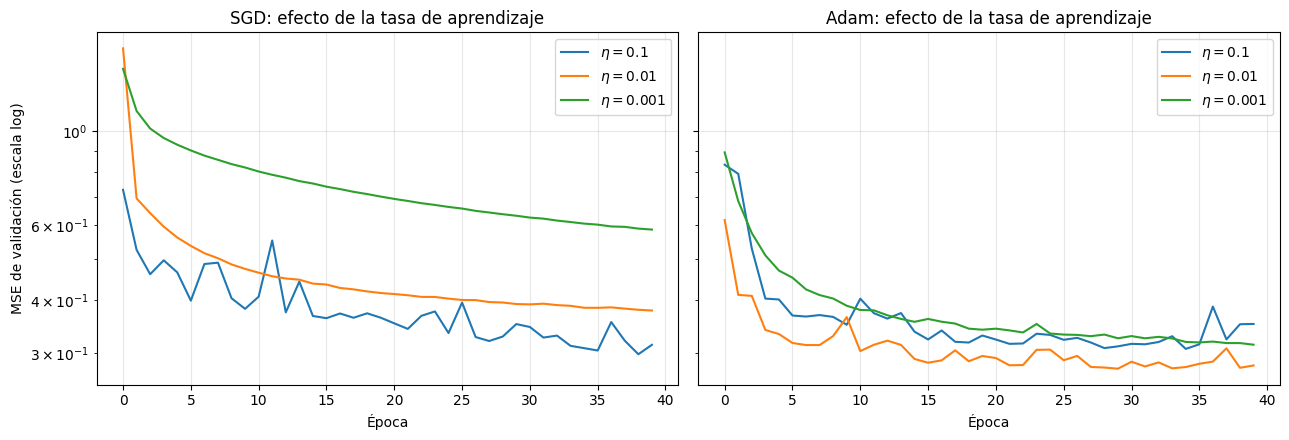

In [13]:
tasas = [0.1, 0.01, 0.001]
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (nombre, clase) in zip(axs, [('SGD', SGD), ('Adam', Adam)]):
    for lr in tasas:
        red = MLP(X_train.shape[1], semilla=SEMILLA)
        _, hist_val = entrenar(red, clase(lr=lr), X_train, y_train,
                               X_val, y_val, epocas=40)
        ax.plot(hist_val, label=fr'$\eta = {lr}$')
        print(f'{nombre} con lr={lr}: MSE de validación final = {hist_val[-1]:.4f}')
    ax.set_title(f'{nombre}: efecto de la tasa de aprendizaje')
    ax.set_xlabel('Época')
    ax.set_yscale('log')
    ax.grid(alpha=0.3)
    ax.legend()
axs[0].set_ylabel('MSE de validación (escala log)')
plt.tight_layout()
plt.show()

### Preguntas

**a) ¿Qué optimizador converge más rápido?**

Los métodos **adaptativos** (Adam, AdamW y RMSProp) y **SGD con momentum** reducen la pérdida mucho más rápido que SGD clásico: en las primeras ~10 épocas ya alcanzan niveles de MSE que a SGD le toman las 100 épocas completas (véanse las curvas comparativas en escala logarítmica). Adam, AdamW y RMSProp son los más rápidos en las primeras épocas; AdaGrad arranca rápido pero se va frenando conforme acumula la suma de gradientes al cuadrado, que hace decrecer su tasa efectiva.

**b) ¿Qué optimizador logra menor error de validación?**

**AdamW y Adam** obtienen el menor MSE de validación (≈ 0.27–0.28), seguidos de SGD con momentum y AdaGrad (≈ 0.29); SGD clásico queda claramente atrás (≈ 0.34) con la misma cantidad de épocas. RMSProp, pese a converger rápido al inicio, termina con un error de validación mayor (≈ 0.32) y curvas más oscilantes, señal de que con esta tasa da pasos algo ruidosos cerca del óptimo. En la tabla de prueba Adam y AdamW también encabezan, con $R^2 \approx 0.78$. Todos los optimizadores superan con holgura a la regresión lineal de referencia ($R^2 \approx 0.60$), lo que confirma que la red captura relaciones no lineales (p. ej. el efecto de la ubicación geográfica) que el modelo lineal del Ejercicio 2 no puede representar.

**c) ¿Hay evidencia de sobreajuste?**

Sobreajuste **fuerte, no**. Las curvas de validación no muestran la típica forma de "U" (no vuelven a subir), y la brecha entre pérdida de entrenamiento y validación es moderada. Sí se aprecia una brecha algo mayor en los optimizadores que más minimizan el entrenamiento (Adam, AdamW, RMSProp), lo cual es esperable: al ajustar mejor los datos de entrenamiento aparecen los primeros indicios de sobreajuste. El *weight decay* de AdamW actúa como regularización y ayuda a que su error de validación sea igual o mejor que el de Adam pese a un ajuste similar en entrenamiento. Si entrenáramos muchas más épocas o con una red más grande, convendría usar paro temprano (*early stopping*) monitoreando la pérdida de validación.

**d) ¿Cómo afecta la tasa de aprendizaje al desempeño?**

Es el hiperparámetro **más crítico**, y el experimento muestra que **SGD es mucho más sensible** a su elección que Adam: con $\eta = 0.001$ SGD se queda muy lejos del óptimo en 40 épocas (MSE ≈ 0.59, casi el doble del mejor resultado), mientras que con $\eta = 0.1$ sí converge bien en este problema (aunque tasas grandes pueden volverlo inestable en general). Adam, en cambio, se mantiene en un rango mucho más estrecho con las tres tasas (MSE entre ≈ 0.28 y ≈ 0.35): con $\eta = 0.001$ solo se retrasa un poco y con $\eta = 0.1$ se vuelve algo ruidoso, pero nunca se degrada tanto como SGD. Esto se debe a su reescalamiento adaptativo por coordenada ($1/\sqrt{\hat v}$), que normaliza el tamaño efectivo del paso. En resumen: los métodos adaptativos son más robustos a la elección de $\eta$, una de las razones prácticas de su popularidad, aunque no eliminan por completo la necesidad de calibrarla.

## 4. Conclusiones

* Manteniendo fija la arquitectura ($8 \to 64 \to 32 \to 1$), la inicialización y los minilotes, el **optimizador por sí solo cambia sustancialmente** tanto la velocidad de convergencia como la calidad final del modelo.
* Los métodos con **momento y/o adaptación de la tasa por coordenada** (momentum, RMSProp, Adam, AdamW) dominan a SGD clásico en este problema: convergen en una fracción de las épocas y alcanzan menor error de validación y prueba.
* **Adam y AdamW** resultaron los mejores: AdamW logró el menor error de validación y Adam el menor error de prueba, ambos con $R^2 \approx 0.78$, combinando rapidez de convergencia con buen desempeño final (en AdamW ayuda además la regularización del *weight decay* desacoplado).
* **AdaGrad** confirma su comportamiento teórico: buen arranque, pero su tasa efectiva decae monótonamente y su avance se va frenando; aun así, en este problema terminó competitivo con SGD + momentum. **RMSProp** convergió rápido al inicio pero con esta tasa mostró curvas oscilantes y quedó por detrás de Adam/AdamW, ilustrando que los promedios exponenciales de gradientes al cuadrado no sustituyen una buena calibración de $\eta$.
* No hubo sobreajuste severo en 100 épocas, aunque los optimizadores más agresivos muestran una brecha entrenamiento–validación mayor; el *weight decay* de AdamW la mitiga.
* La **tasa de aprendizaje** es determinante: SGD la requiere bien calibrada, mientras que Adam es notablemente robusto a ella.
* La red neuronal supera con claridad a la regresión lineal del Ejercicio 2 ($R^2$ de ≈ 0.78 vs. ≈ 0.61), evidenciando la capacidad de las MLP para capturar no linealidades e interacciones (p. ej. entre latitud y longitud).

## Referencias

* Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press. Capítulo 8: Optimization for Training Deep Models. Disponible en: [deeplearningbook.org](http://www.deeplearningbook.org)
* Kingma, D. P., & Ba, J. (2015). Adam: A Method for Stochastic Optimization. *ICLR 2015*. [arXiv:1412.6980](https://arxiv.org/abs/1412.6980)
* Loshchilov, I., & Hutter, F. (2019). Decoupled Weight Decay Regularization. *ICLR 2019*. [arXiv:1711.05101](https://arxiv.org/abs/1711.05101)
* Pace, R. K., & Barry, R. (1997). Sparse spatial autoregressions. *Statistics & Probability Letters*, 33(3), 291–297. (Base de datos California Housing.)
* Documentación de scikit-learn: [`fetch_california_housing`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html)